# 🔆 Overview
This notebook imports **final_df from "Data_cleaning_split.ipynb"**, splits the data into train/test sets, and builds a baseline model - a logistic regresion model. Here, we **predict the normal_range or not using the past 30-minute data to predict the current range of glucose level. If the subgroup data has data from less than 30 minutes, we take in what is available. Also, for gaps larger than 30 minutes, we look back upto 60 minutes, the maximum value that the gaps can be.

* Note: due to the way that logistic regression models work, we take the statistics of past 30 minutes glucose levels and then use them as input features.

* Note: we do **not use synthetic data** here

**Train/test split**: time-based split
* For each ID, we use the first 80% of the timestamp for training, 20% for testing
* This approach preserves chronical order and avoids potential data leakage
* Here, we also check the class distribution in train set so that rare cases such as hypoglycemia don't end up just being in either set - which will ensure that the model will learn pattenrs for all classes
  
   1️⃣ time-based split per ID to avoid data leakage
  
   2️⃣ check the class distribution in train set
   
   3️⃣ if there's an unrepresented class, we oversample that class to balance the train/test sets
  
* **All canine subsets are in the train/test set, and there is no random sampling**

**Additional Weighting**
* To account for glucose levels that may have greater impact (e.g., those that were measured more recently would be more likely to be closer to the current data point), we apply weights in calculating the mean and the slope

**Model input** (7)
* **mean_glucose**: overall level of glucose within the past 30 minutes
* **min_glucose**: detects dips for hypoglycemia risk, *weighted*
* **max_glucose**: detects dips for hyperglycemia risk
* **last_glucose**: the most recent measurement as a short-term reference
* **slope**: aim to capture the overall trend in glucose fluctuation, *weighted*
* **mean_gap**: captures density of readings
  * for example, some data points might have 5 past data points within the 30-minute time window, while some points might have only 2 past data points to refer to
* **gap_min**: already in the data. used for indicating the time difference of the current time point with the most recent measure
* **num_readings**: number of readings in the past 30 minutes (or past 60 minutes if there are no readings from the past 30 minutes)

**Label**
: To allow for flexible change between predicting 'normal_range' and 'glucose_category', we set the label as 'target'

**Additional Model input**

* **Volatility**
  * std_glucose: standard deviation of glucose values in window
  * range_glucose: difference between min and max glucose
  * mean_abs_change: mean absolute diff between consecutive readings

* **Trend**
  * delta_glucose: diff between last and first glucose levels in window

* **Threshold distance**
  * dist_low: distance from last glucose to lower threshold
  * dist_high: distance from last glucose to upper threshold
  * dist_nearest: distance to whichever threshold is closer

* **Exposure**
  * pct_near_low: faction of readings within [low_th, low_th + 15]
  * pct_near_high: faction within [high_th -15, high_th]
  * pct_below_low: fraction below low_th
  * pct_above_high: fraction above high_th

* **Time context**
  * hour: hour of day
  * weekday: day of week
  * overnight_flag: whether timestamp between 12AM - 5AM



---

# 🔆 Setup / Importing Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# for CNN
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [ ]:
# mounting on gdrive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import data
# WooJung
# data_path = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/data_0228"

# Ainsley


# Ci
data_path = "/content/drive/MyDrive/210 Capstone/data_0228"

In [ ]:
# importing data
file = os.path.join(data_path, "final_df.pkl")

try:
  with open(file, "rb") as f:
    final_df = pickle.load(f)
except FileNotFoundError:
  print(f"Error: file {file} not found in {data_path}")

In [ ]:
final_df.head()

,ID,timestamp,glucose,glucose_category,normal_range,gap_min
0,canine1-001,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN
1,canine1-001,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0
2,canine1-001,2025-11-01 06:21:00,373.0,hyperglycemia,False,15.0
3,canine1-001,2025-11-01 06:36:00,375.0,hyperglycemia,False,15.0
4,canine1-001,2025-11-01 06:51:00,376.0,hyperglycemia,False,15.0


In [ ]:
final_df.groupby("glucose_category")["timestamp"].count().reset_index(name = "Count")

,glucose_category,Count
0,hyperglycemia,19867
1,hypoglycemia,331
2,normal,11109


In [ ]:
# check that the max gap is smaller than 60 minutes
final_df["gap_min"].describe()

,gap_min
count,31009.000000
mean,11.667774
std,6.475288
min,1.000000
25%,6.000000
50%,15.000000
75%,15.000000
max,58.000000


# 🔆 Feature Engineering

## ⭐ Lookback window, generating features

In [ ]:
def feature_engineering(
    df,
    window_default = 30,
    window_max = 60,
    decay_min = 15,
    low_th = 65,
    high_th = 250
):

    features = [] # List to store dictionaries of engineered features for each data point

    for id, group in df.groupby("ID"):

        # Iterate through each row (glucose measurement) for the current canine
        for i, row in group.iterrows():

            # Define the start of the default time window (e.g., current_time - 30 minutes)
            window_start = row["timestamp"] - pd.Timedelta(minutes=window_default)
            # Define the start of the maximum lookback window (e.g., current_time - 60 minutes)
            lookback_start = row["timestamp"] - pd.Timedelta(minutes=window_max)

            # --- Lookback Window Logic --- #
            # Select past glucose readings within the default window (excluding the current timestamp)
            time_window = group[
                (group["timestamp"] >= window_start) &
                (group["timestamp"] < row["timestamp"])
            ]

            # If no data is found in the default window, expand the search to the maximum lookback window
            if len(time_window) == 0:
                time_window = group[
                    (group["timestamp"] >= lookback_start) &
                    (group["timestamp"] < row["timestamp"])
                ]

            # If still no data is found in the lookback window, skip this row as features cannot be computed
            if len(time_window) == 0:
                continue

            glucose_values = time_window["glucose"].values # Extract glucose values from the time window

            # ------------------------- #
            # BASIC FEATURES            #
            # ------------------------- #

            min_glucose = glucose_values.min() # Minimum glucose value in the window
            max_glucose = glucose_values.max() # Maximum glucose value in the window
            last_glucose = glucose_values[-1] # The most recent glucose value in the window

            # --- Weighting for Recency (Exponential Decay) ---
            # Calculate the time difference (in minutes) of each past reading from the current timestamp
            time_gap = (row["timestamp"] - time_window["timestamp"]).dt.total_seconds()/60
            # Apply exponential decay to calculate weights: exp(-(time_gap / decay_min))
            # More recent readings (smaller time_gap) get higher weights.
            weights = np.exp(-(time_gap/decay_min))

            # Calculate a weighted mean of glucose values using the computed weights
            weighted_mean = np.average(glucose_values, weights=weights)

            # Calculate a weighted sum of time gaps. This is used in the slope calculation to account for uneven time spacing
            weighted_time = np.sum(weights * time_window["gap_min"].fillna(0))

            # Skip if weighted_time is zero to avoid division by zero in slope calculation
            if weighted_time == 0:
                continue

            # Calculate the slope of glucose change: (change in glucose) / (weighted change in time)
            slope = (last_glucose - glucose_values[0]) / weighted_time

            mean_gap = time_window["gap_min"].mean() # Average 'gap_min' within the window

            # ------------------------- #
            # VOLATILITY FEATURES       #
            # ------------------------- #

            std_glucose = np.std(glucose_values) # Standard deviation of glucose values

            range_glucose = max_glucose - min_glucose # Range of glucose values (max - min)

            # Calculate mean absolute change between consecutive glucose readings
            if len(glucose_values) > 1:
                mean_abs_change = np.mean(np.abs(np.diff(glucose_values)))
            else:
                mean_abs_change = 0 # If only one reading, no change

            # ------------------------- #
            # TREND FEATURES            #
            # ------------------------- #

            delta_glucose = last_glucose - glucose_values[0] # Change from the first to the last glucose reading

            # ------------------------- #
            # THRESHOLD DISTANCE        #
            # ------------------------- #

            dist_low = last_glucose - low_th # Distance from last glucose to lower threshold
            dist_high = high_th - last_glucose # Distance from last glucose to upper threshold

            dist_nearest = min(dist_low, dist_high) # Distance to the nearest threshold

            # ------------------------- #
            # EXPOSURE FEATURES         #
            # ------------------------- #

            # Percentage of readings near the lower threshold (e.g., within 15 units above low_th)
            pct_near_low = np.mean(
                (glucose_values >= low_th) &
                (glucose_values <= low_th + 15)
            )

            # Percentage of readings near the higher threshold (e.g., within 15 units below high_th)
            pct_near_high = np.mean(
                (glucose_values >= high_th - 15) &
                (glucose_values <= high_th)
            )

            pct_below_low = np.mean(glucose_values < low_th) # Percentage of readings below the lower threshold
            pct_above_high = np.mean(glucose_values > high_th) # Percentage of readings above the higher threshold

            # ------------------------- #
            # TIME FEATURES             #
            # ------------------------- #

            hour = row["timestamp"].hour # Hour of the current timestamp
            weekday = row["timestamp"].weekday() # Day of the week of the current timestamp

            # Flag for overnight hours (e.g., 0-5 AM)
            overnight_flag = 1 if hour in [0,1,2,3,4,5] else 0

            # ------------------------- #
            # APPEND ALL FEATURES       #
            # ------------------------- #

            # Append a dictionary of all calculated features and original labels to the features list
            features.append({

                "ID": id,
                "timestamp": row["timestamp"],

                # Original features (as specified in the problem description)
                "mean_glucose": weighted_mean,
                "min_glucose": min_glucose,
                "max_glucose": max_glucose,
                "slope": slope,
                "last_glucose": last_glucose,
                "mean_gap": mean_gap,
                "gap_min": row["gap_min"], # Directly from the original DataFrame for the current row
                "num_readings": len(time_window), # Number of glucose readings in the time window

                # Volatility features
                "std_glucose": std_glucose,
                "range_glucose": range_glucose,
                "mean_abs_change": mean_abs_change,

                # Trend features
                "delta_glucose": delta_glucose,

                # Threshold distance features
                "dist_low": dist_low,
                "dist_high": dist_high,
                "dist_nearest": dist_nearest,

                # Exposure features
                "pct_near_low": pct_near_low,
                "pct_near_high": pct_near_high,
                "pct_below_low": pct_below_low,
                "pct_above_high": pct_above_high,

                # Time context features
                "hour": hour,
                "weekday": weekday,
                "overnight_flag": overnight_flag,

                # Labels (copied directly from the original DataFrame for the current row)
                "glucose_category": row["glucose_category"],
                "normal_range": row["normal_range"]

            })

    # Convert the list of feature dictionaries into a Pandas DataFrame
    return pd.DataFrame(features)

In [ ]:
feature_df = feature_engineering(
    final_df,
    window_default = 60,
    window_max = 120,
    decay_min = 15,
    low_th = 65,
    high_th = 250
)

In [ ]:
# define target
# normal_range = 1 means safe, 0 means out-of-range
feature_df["unsafe_now"] = (feature_df["normal_range"] == 0).astype(int)

# all candidate input features
feature_cols = [
    # level
    "mean_glucose",
    "min_glucose",
    "max_glucose",
    "last_glucose",

    # trend
    "slope",
    "delta_glucose",

    # volatility
    "std_glucose",
    "range_glucose",
    "mean_abs_change",

    # threshold distance
    "dist_low",
    "dist_high",
    "dist_nearest",

    # exposure
    "pct_near_low",
    "pct_near_high",
    "pct_below_low",
    "pct_above_high",

    # timing / sampling
    "mean_gap",
    "gap_min",
    "num_readings",

    # time context
    "hour",
    "weekday",
    "overnight_flag"
]

# keep only rows with complete values for selected features + target
model_df = feature_df.dropna(subset=feature_cols + ["unsafe_now"]).copy()


print("feature_df shape:", feature_df.shape)
print("model_df shape after dropna:", model_df.shape)
print("\nClass balance:")
print(model_df["unsafe_now"].value_counts(dropna=False))
print("\nClass proportion:")
print(model_df["unsafe_now"].value_counts(normalize=True).round(4))

feature_df shape: (30711, 27)
model_df shape after dropna: (30711, 27)

Class balance:
unsafe_now
1    19806
0    10905
Name: count, dtype: int64

Class proportion:
unsafe_now
1    0.6449
0    0.3551
Name: proportion, dtype: float64


In [ ]:
# create a df for the feature selection EDA
eda_df = model_df[
    ["ID", "timestamp", "unsafe_now"] + feature_cols
].copy()

eda_df.head()

,ID,timestamp,unsafe_now,mean_glucose,min_glucose,max_glucose,last_glucose,slope,delta_glucose,std_glucose,...,pct_near_low,pct_near_high,pct_below_low,pct_above_high,mean_gap,gap_min,num_readings,hour,weekday,overnight_flag
0,canine1-001,2025-11-01 06:21:00,1,375.000000,375.0,375.0,375.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,1.0,15.0,15.0,2,6,5,0
1,canine1-001,2025-11-01 06:36:00,1,373.669518,373.0,375.0,373.0,-0.264963,-2.0,0.942809,...,0.0,0.0,0.0,1.0,15.0,15.0,3,6,5,0
2,canine1-001,2025-11-01 06:51:00,1,374.526234,373.0,375.0,375.0,0.000000,0.0,0.866025,...,0.0,0.0,0.0,1.0,15.0,15.0,4,6,5,0
3,canine1-001,2025-11-01 07:06:00,1,375.469626,373.0,376.0,376.0,0.116689,1.0,1.089725,...,0.0,0.0,0.0,1.0,15.0,15.0,4,7,5,0
4,canine1-001,2025-11-01 07:21:00,1,371.953194,370.0,376.0,370.0,-0.350068,-3.0,2.291288,...,0.0,0.0,0.0,1.0,15.0,15.0,4,7,5,0


Univariate EDA for feature selection

This step helps answer:

* does the feature differ between safe vs unsafe?
* is the relationship meaningful?
* should we keep it?



In [ ]:
# Summary table by class
summary_by_class = (
    model_df.groupby("unsafe_now")[feature_cols]
    .agg(["mean", "median", "std"])
    .round(3)
)

summary_by_class.T

unsafe_now                   0        1
mean_glucose   mean    169.197  384.541
               median  169.916  387.635
               std      53.256   91.364
min_glucose    mean    154.115  364.953
               median  153.000  365.000
...                        ...      ...
weekday        median    3.000    3.000
               std       1.870    2.020
overnight_flag mean      0.251    0.218
               median    0.000    0.000
               std       0.434    0.413

[66 rows x 2 columns]

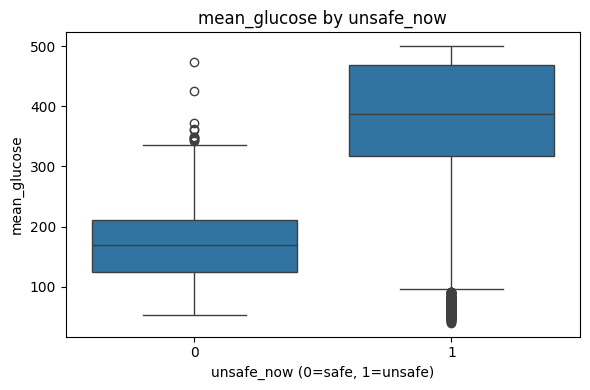

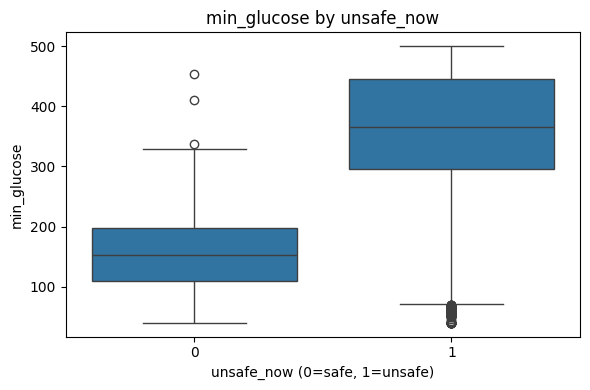

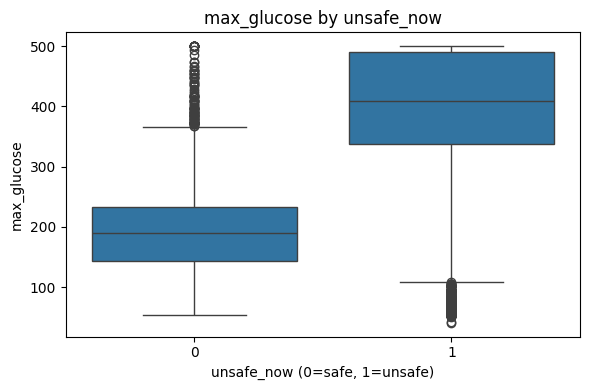

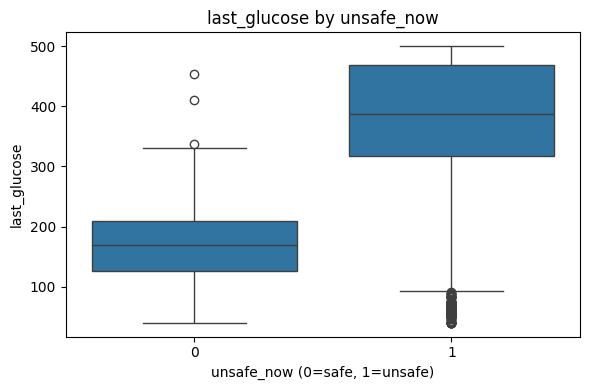

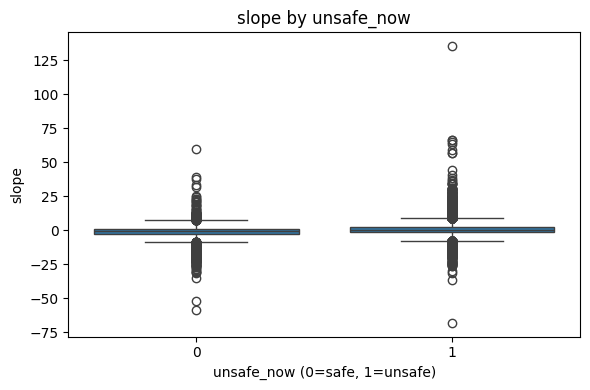

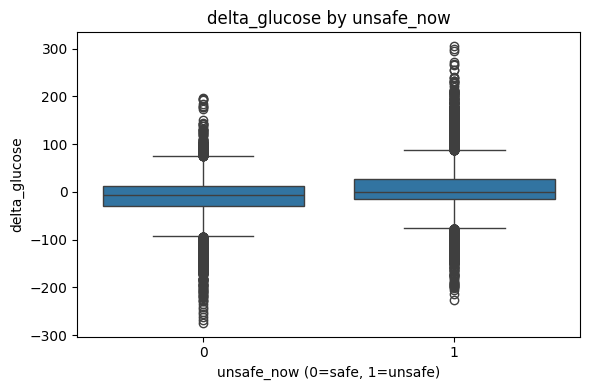

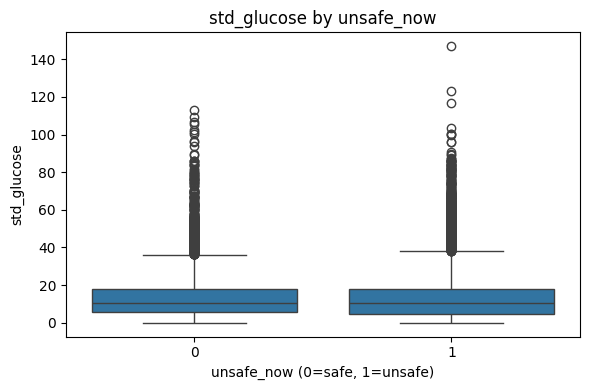

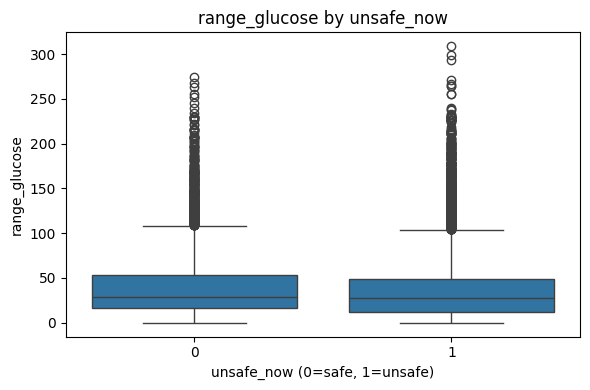

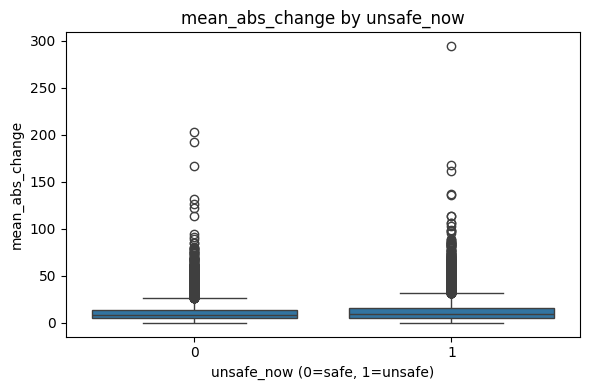

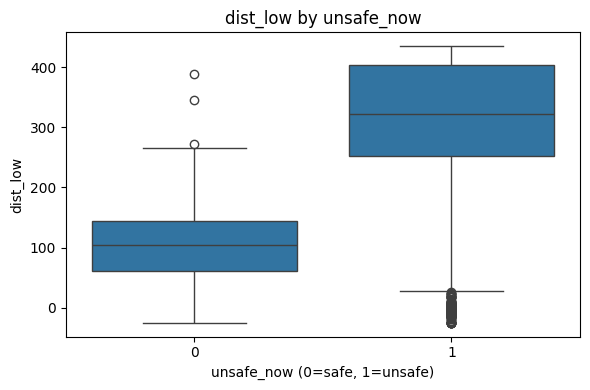

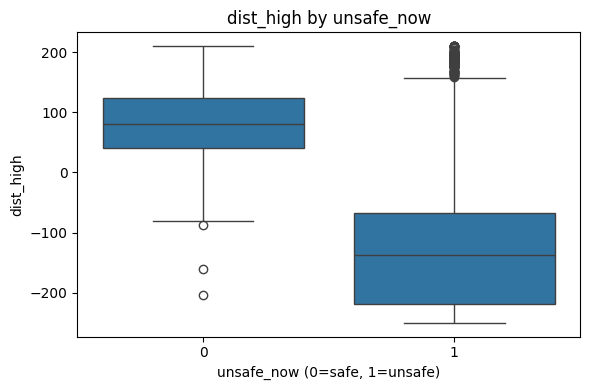

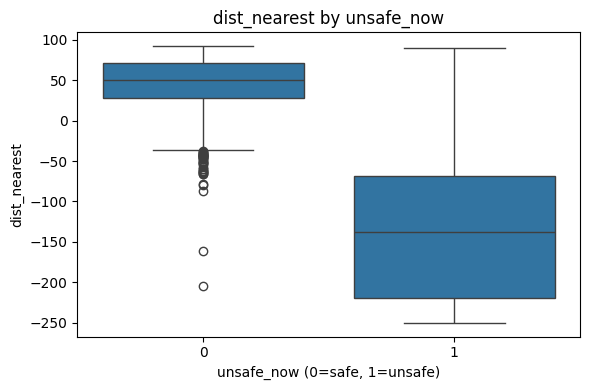

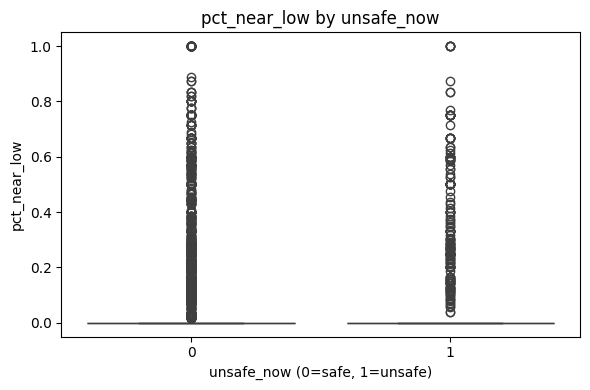

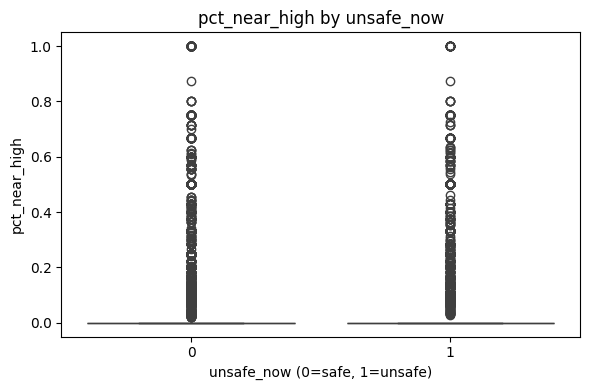

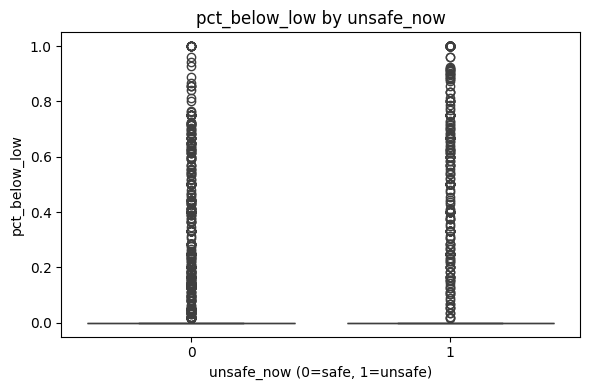

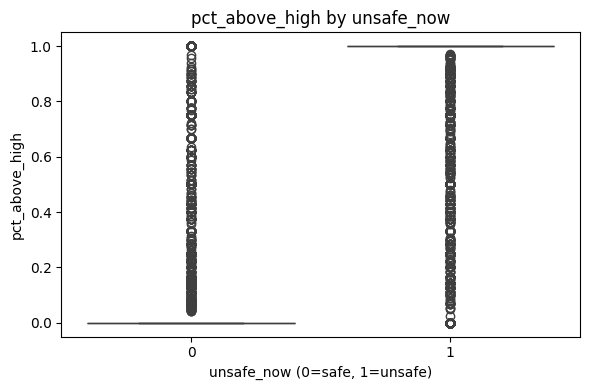

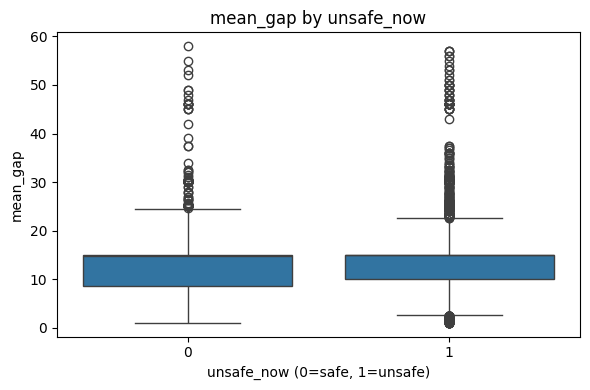

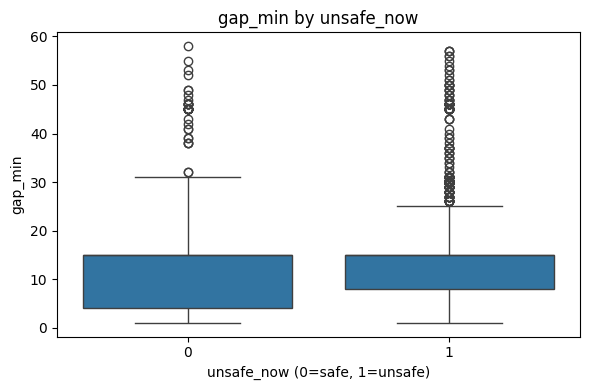

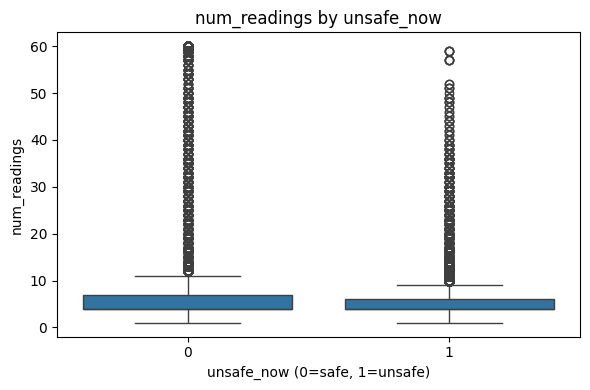

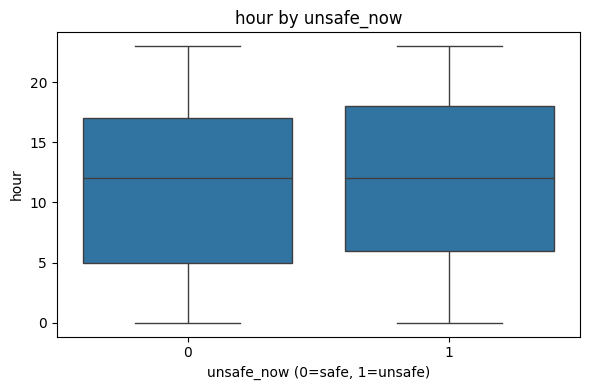

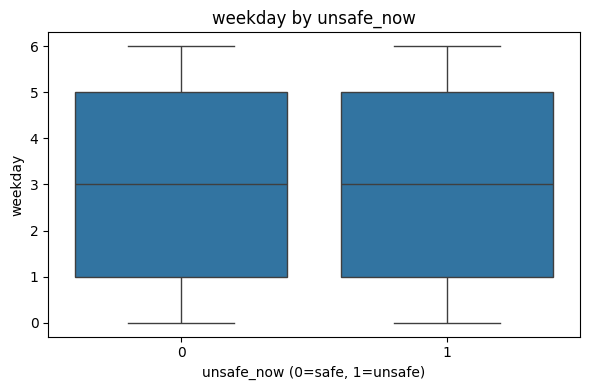

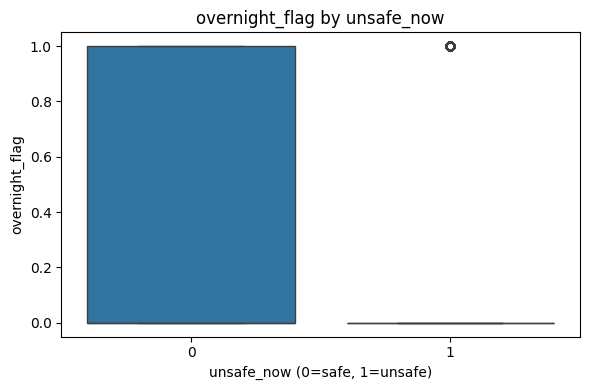

In [ ]:
# Boxplots

for col in feature_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=model_df, x="unsafe_now", y=col)
    plt.title(f"{col} by unsafe_now")
    plt.xlabel("unsafe_now (0=safe, 1=unsafe)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Rule of Thumb: If the unsafe group has a clearly different median and distribution from the safe group, that feature likely has predictive value.

List of Features help differentiation:
* mean/min/max/last_glucose
* dist_low/high/nearest




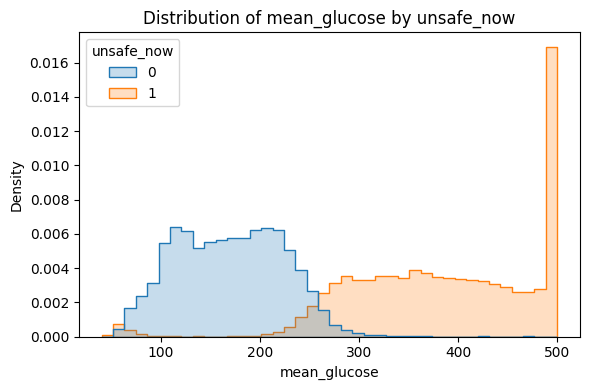

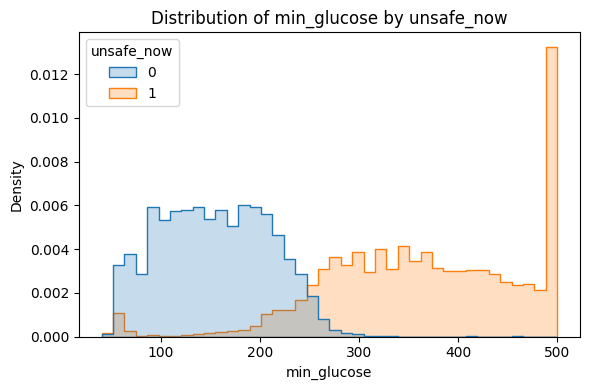

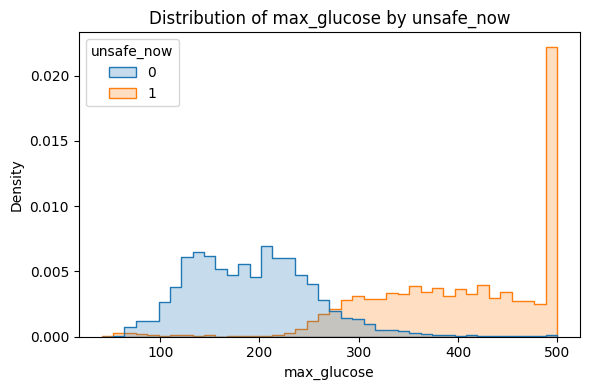

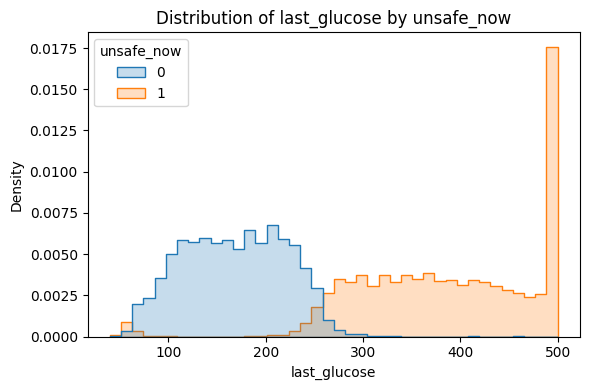

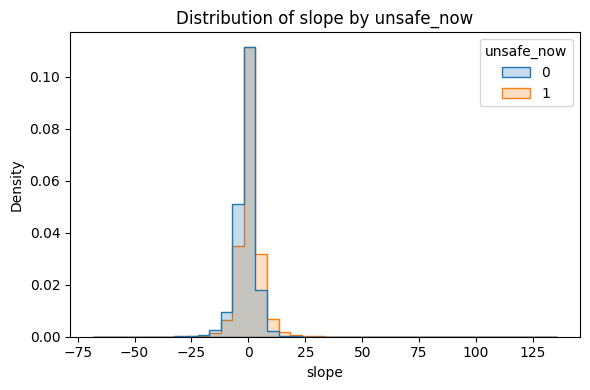

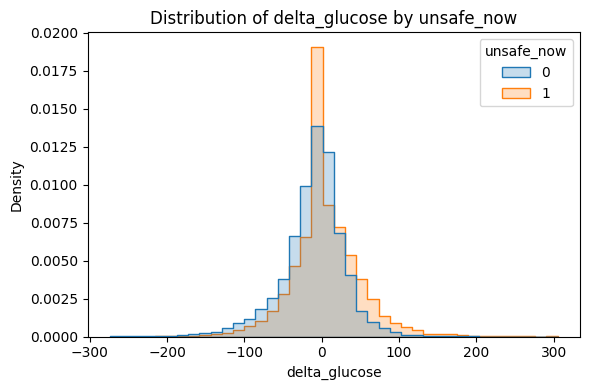

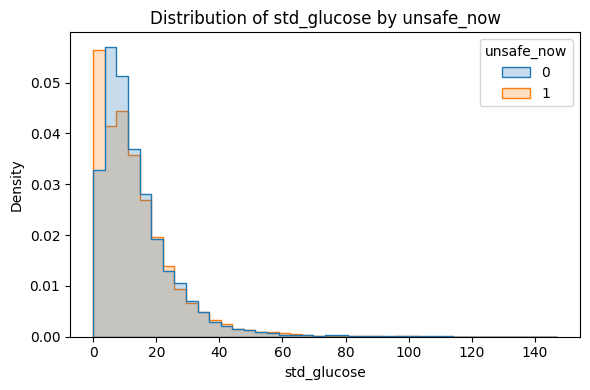

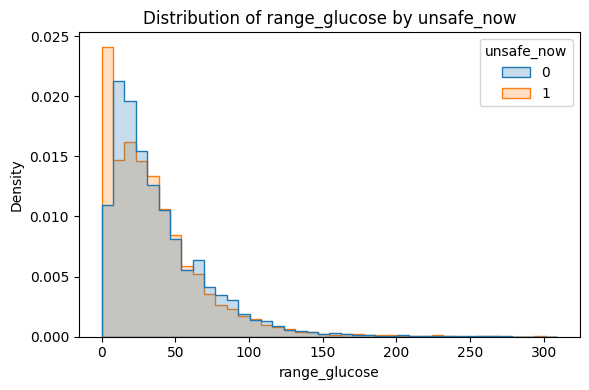

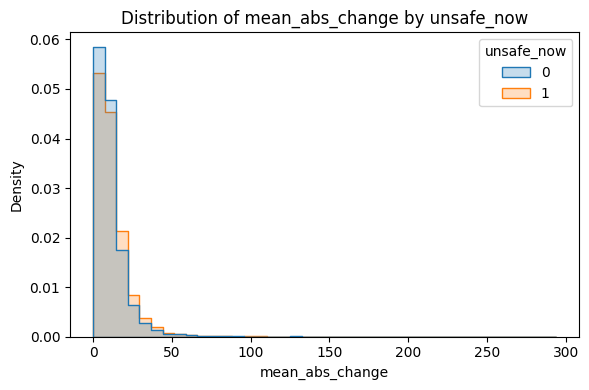

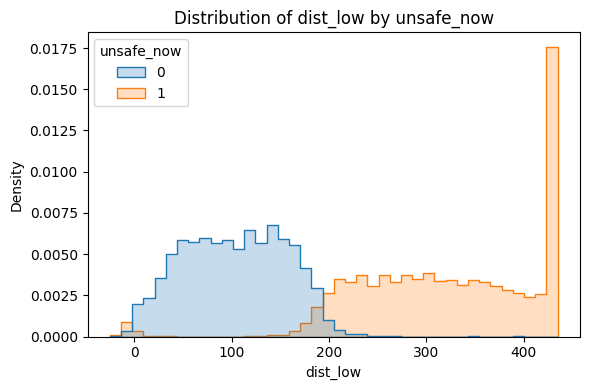

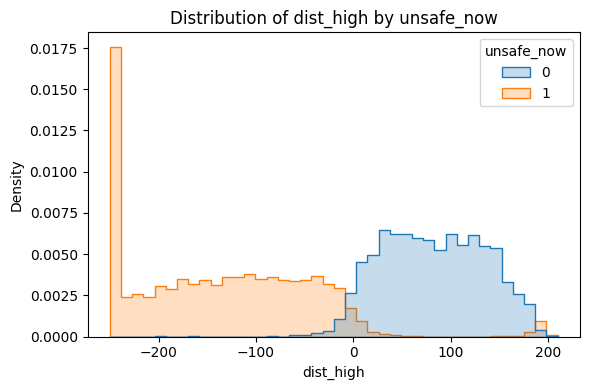

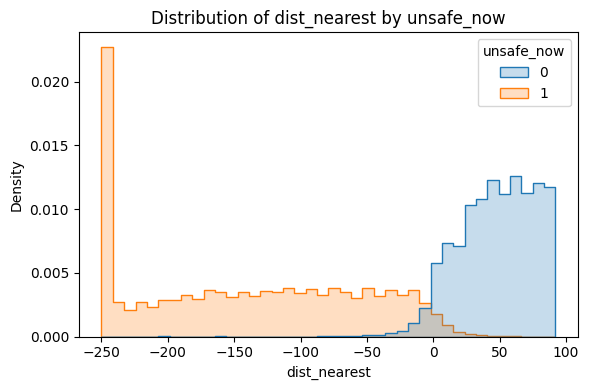

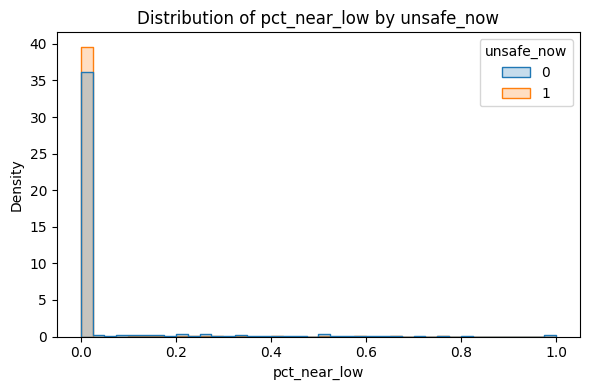

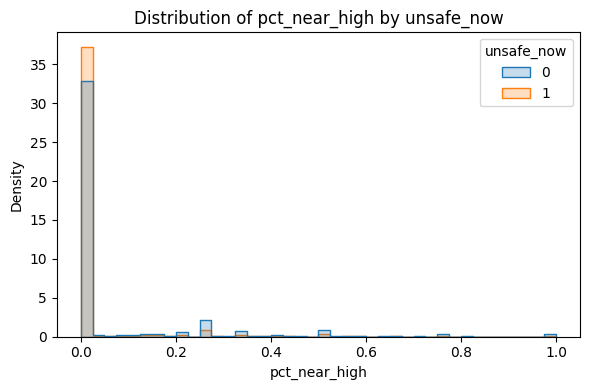

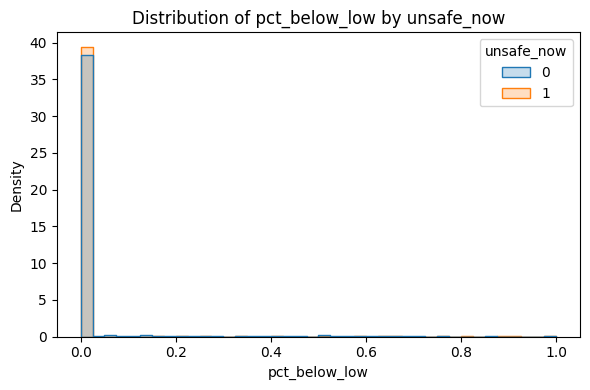

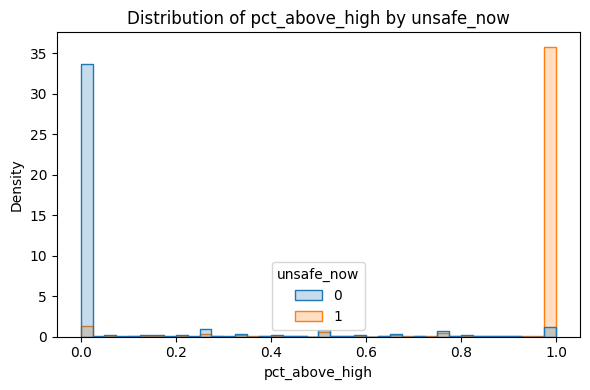

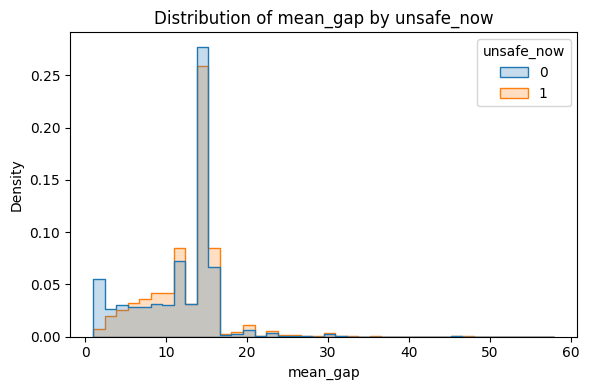

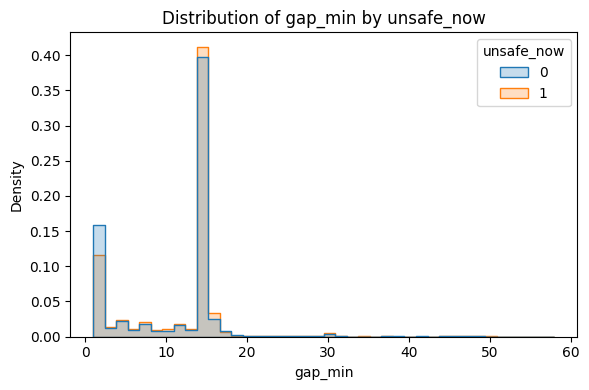

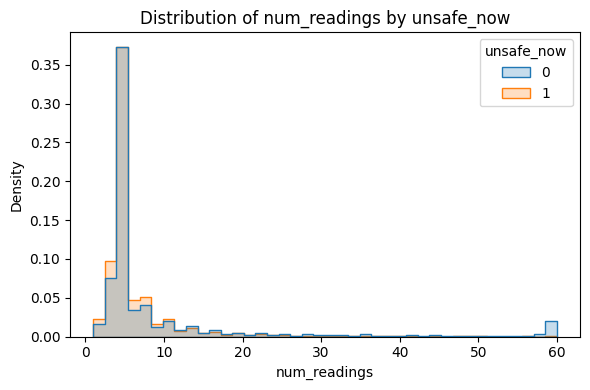

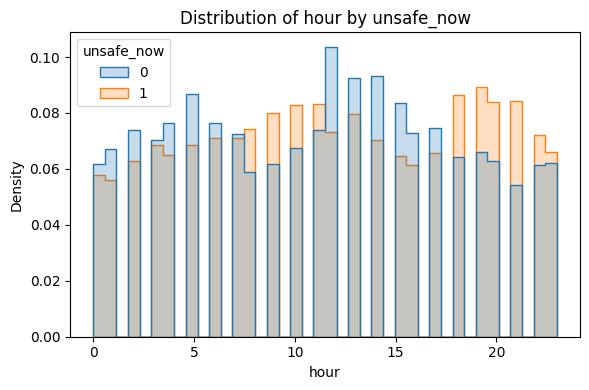

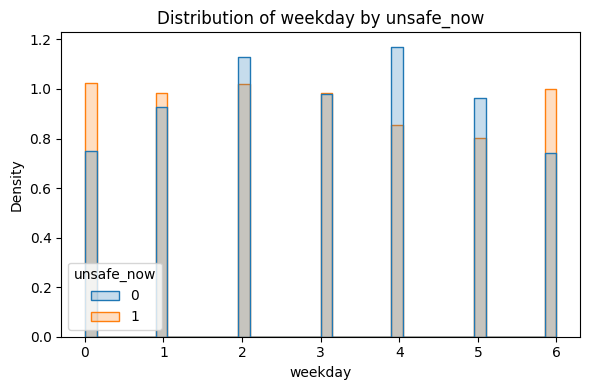

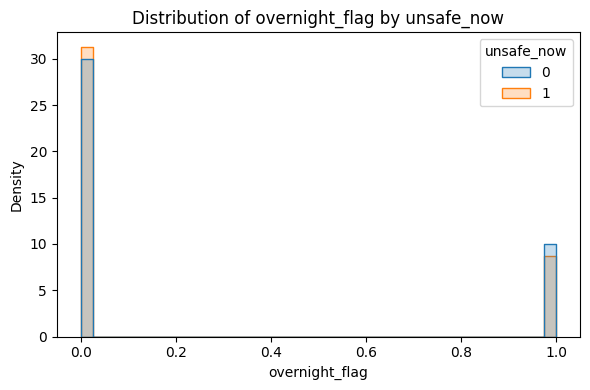

In [ ]:
# distribution plot to see the ovarlaps
for col in feature_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=model_df,
        x=col,
        hue="unsafe_now",
        bins=40,
        stat="density",
        common_norm=False,
        element="step"
    )
    plt.title(f"Distribution of {col} by unsafe_now")
    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.stats import pointbiserialr # correlation coefficient for a continuous-binary pair

feature_scores = []

for col in feature_cols:
    temp = model_df[[col, "unsafe_now"]].dropna()
    if temp[col].nunique() > 1:
        corr, pval = pointbiserialr(temp[col], temp["unsafe_now"])
        feature_scores.append({
            "feature": col,
            "pointbiserial_corr": corr,
            "abs_corr": abs(corr),
            "p_value": pval
        })

feature_scores_df = pd.DataFrame(feature_scores).sort_values("abs_corr", ascending=False)
feature_scores_df

,feature,pointbiserial_corr,abs_corr,p_value
15,pct_above_high,0.875331,0.875331,0.000000e+00
3,last_glucose,0.794298,0.794298,0.000000e+00
9,dist_low,0.794298,0.794298,0.000000e+00
10,dist_high,-0.794298,0.794298,0.000000e+00
11,dist_nearest,-0.792601,0.792601,0.000000e+00
0,mean_glucose,0.790140,0.790140,0.000000e+00
2,max_glucose,0.779453,0.779453,0.000000e+00
1,min_glucose,0.763887,0.763887,0.000000e+00
18,num_readings,-0.184509,0.184509,2.641922e-233
5,delta_glucose,0.180444,0.180444,4.630627e-223




We visualized the unsafe rate across binned feature values.
* if unsafe rate changes clearly across bins, the feature likely carries signal
* if it is flat, the feature may add little

In [ ]:
def plot_event_rate_by_bins(df, feature, target="unsafe_now", q=10):
    # Create a temporary DataFrame with the feature and target, dropping any rows with NaN values
    temp = df[[feature, target]].dropna().copy()

    # Bin the continuous feature into 'q' quantiles. 'duplicates="drop"' handles cases
    temp["bin"] = pd.qcut(temp[feature], q=q, duplicates="drop")

    # Group the temporary DataFrame by these bins and calculate the mean of the target
    # 'observed=False' is important for categorical groupings, ensuring all categories are considered.
    out = (
        temp.groupby("bin", observed=False)[target]
        .agg(["mean", "count"]) # 'mean' gives the event rate, 'count' shows number of samples in bin
        .reset_index()
    )

    # plotting
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Plot the 'unsafe rate' (mean of the target) across the bins as a line plot
    ax1.plot(range(len(out)), out["mean"], marker="o")
    ax1.set_ylabel("Unsafe rate")
    ax1.set_xlabel(f"{feature} bins")
    ax1.set_title(f"Unsafe rate across binned {feature}")
    ax1.set_xticks(range(len(out)))
    ax1.set_xticklabels(out["bin"].astype(str), rotation=45, ha="right")
    ax1.set_ylim([0, 1]) # Ensure y-axis range is from 0 to 1, as it represents a proportion

    plt.tight_layout()
    plt.show()

    return out

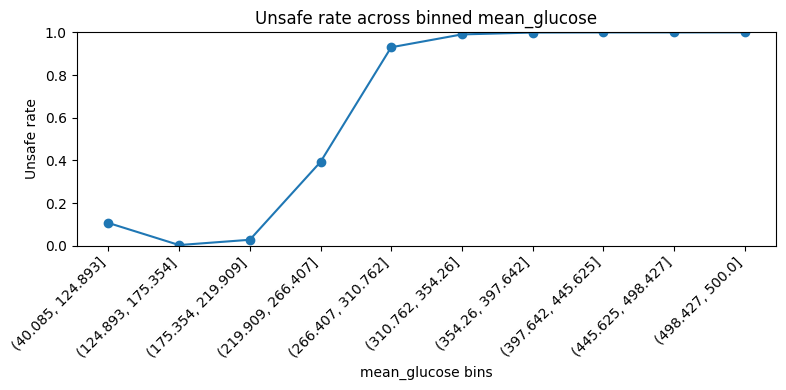

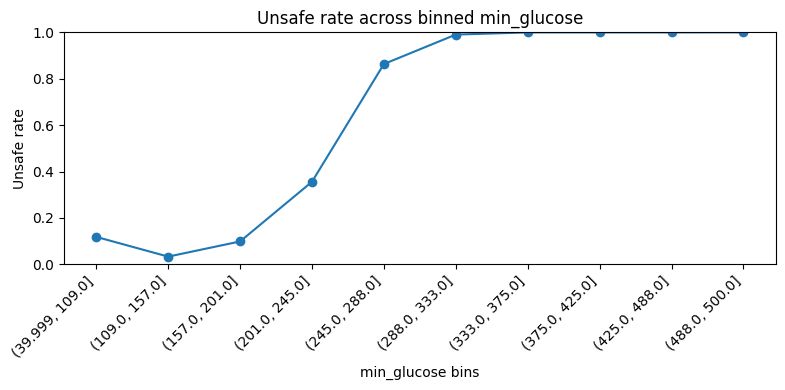

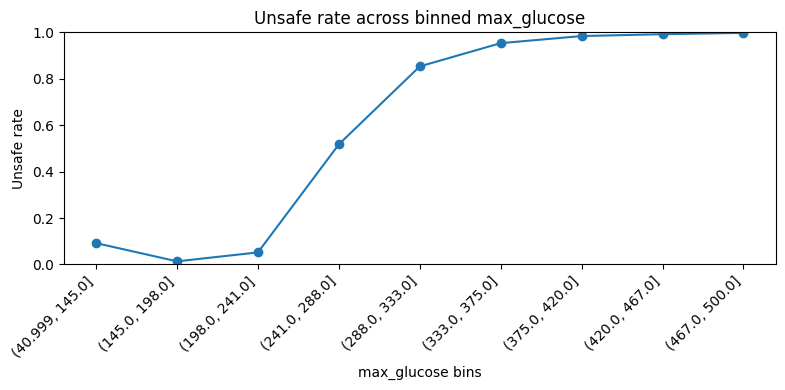

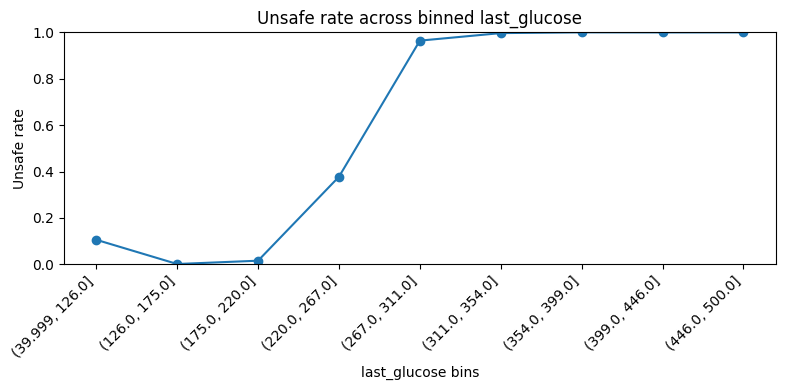

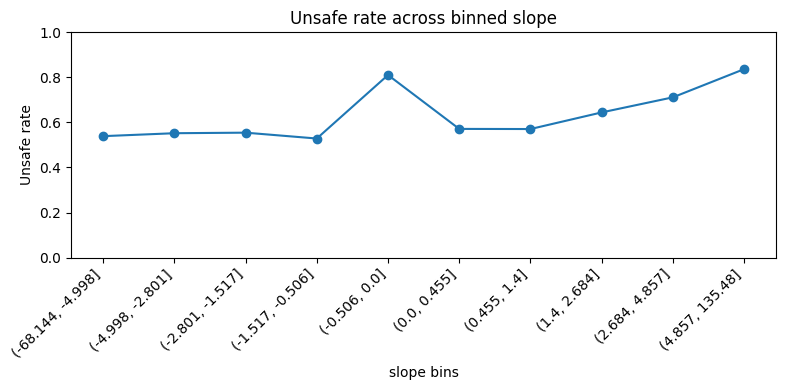

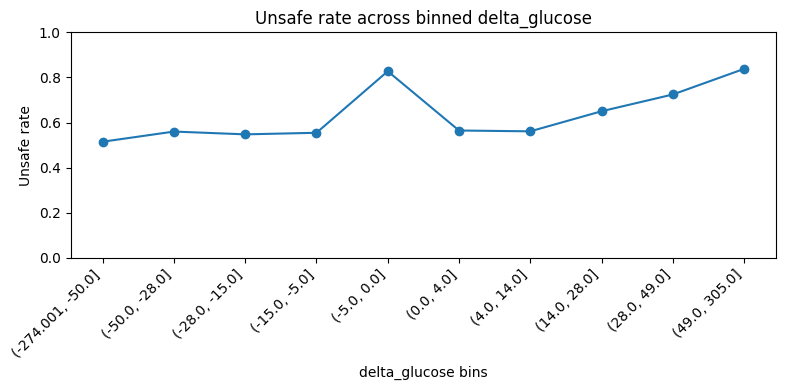

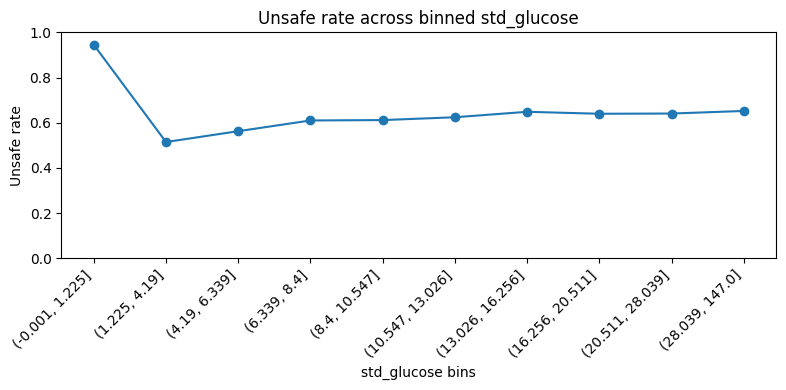

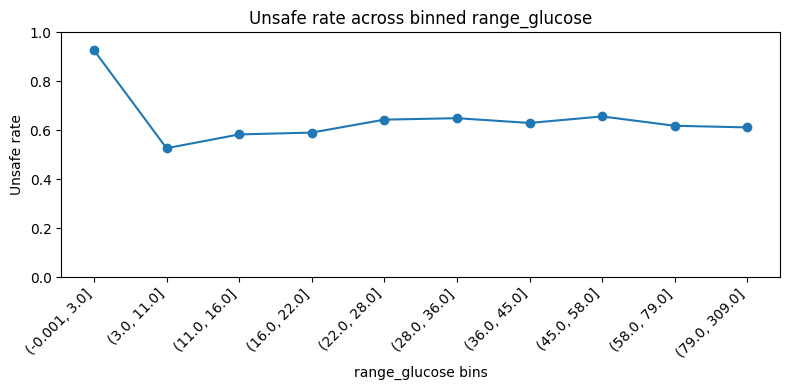

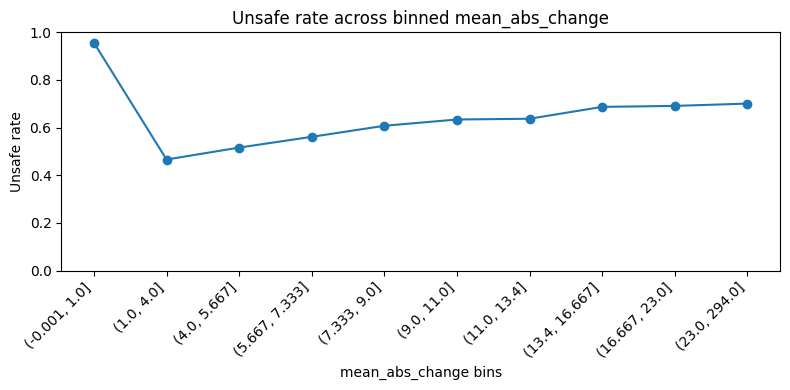

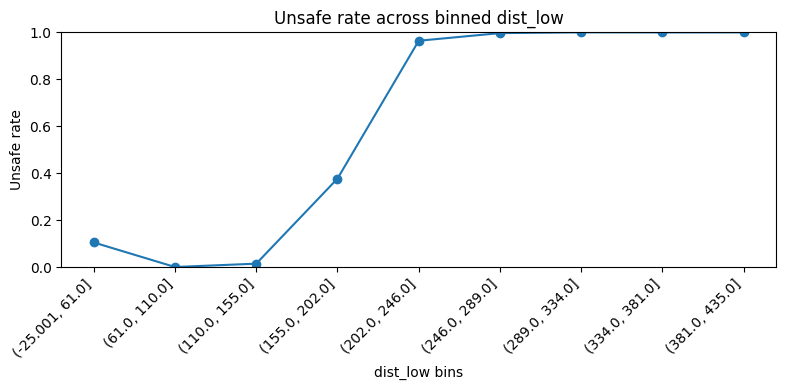

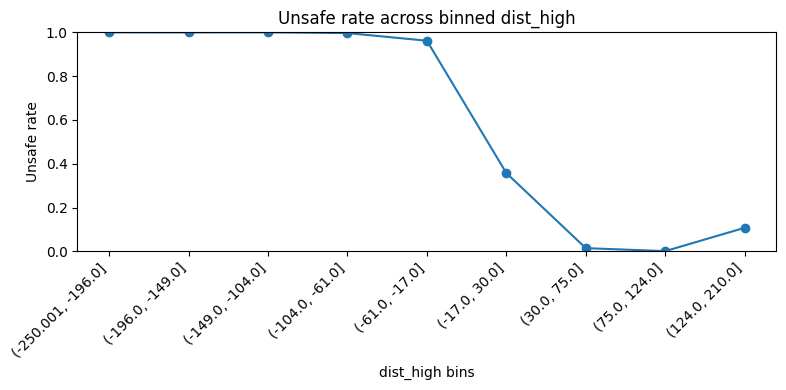

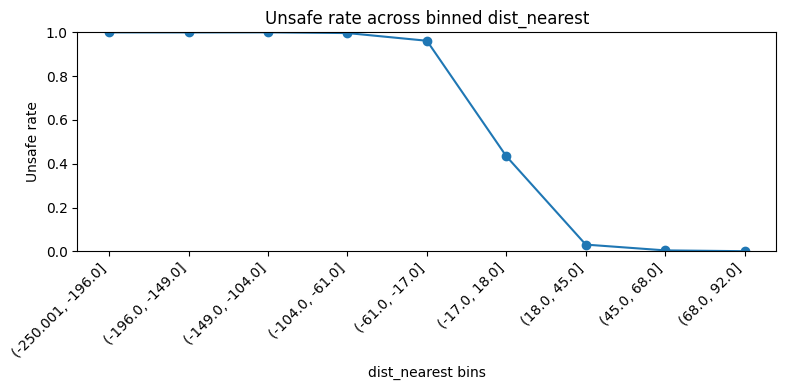

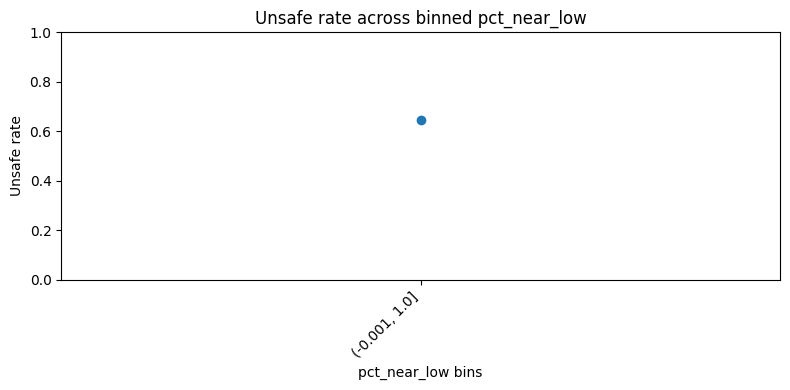

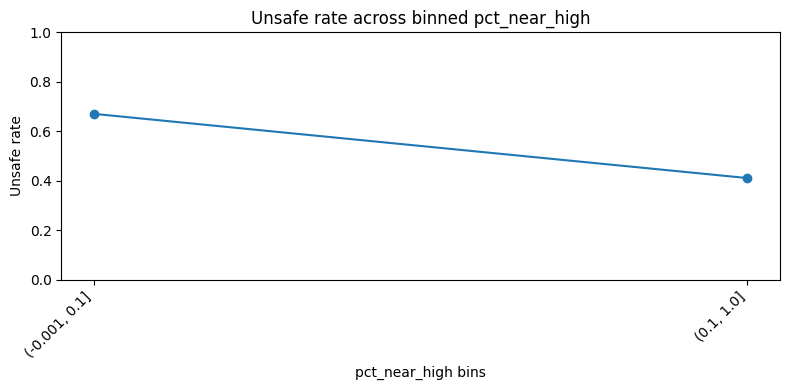

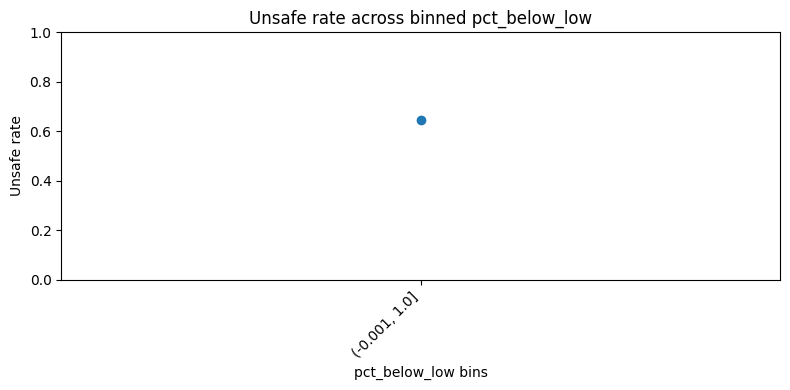

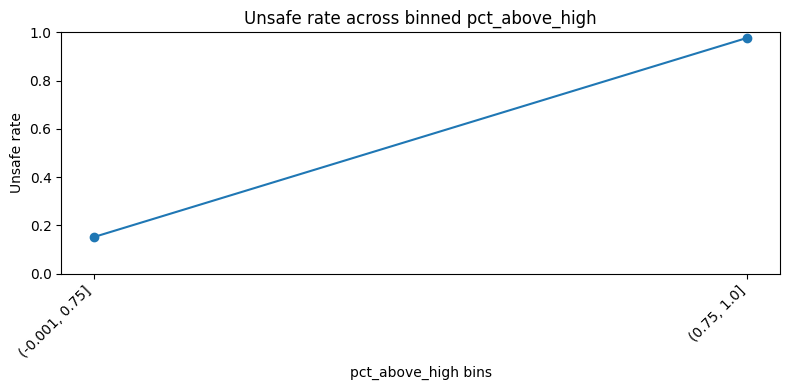

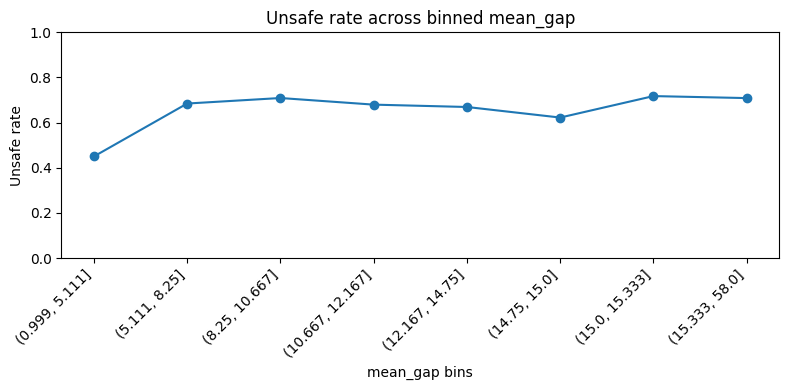

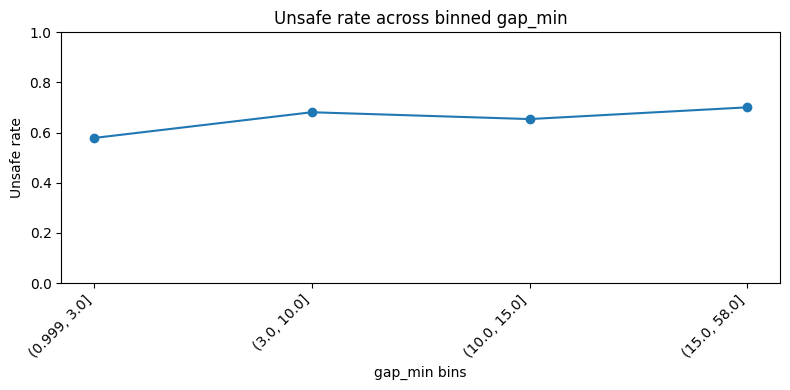

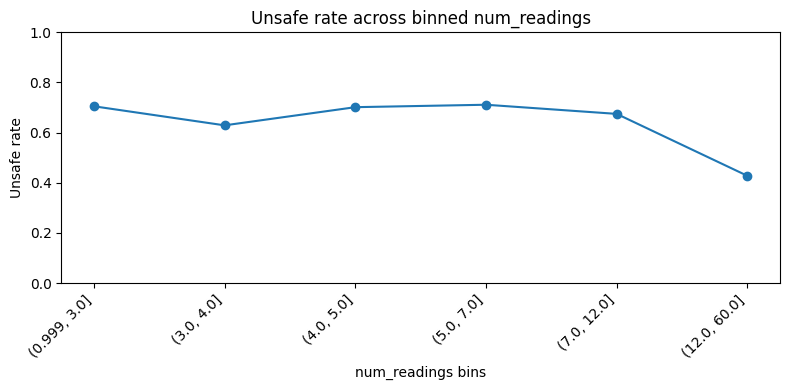

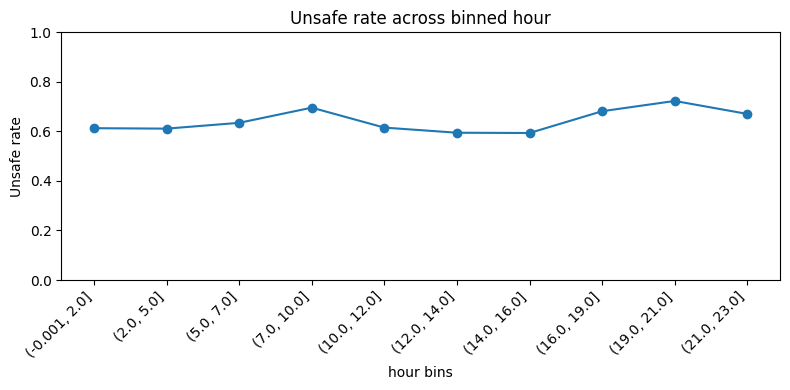

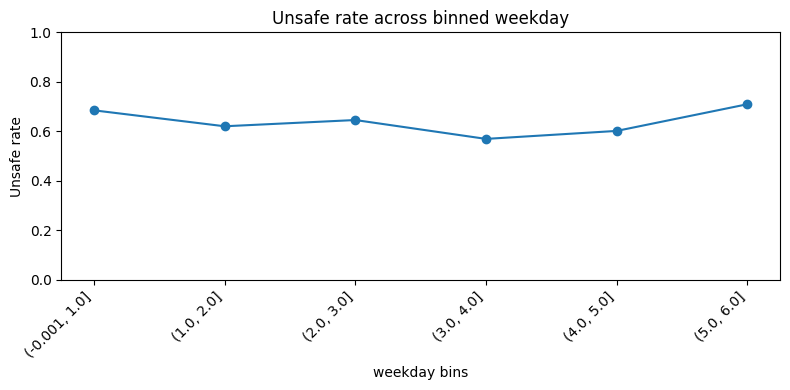

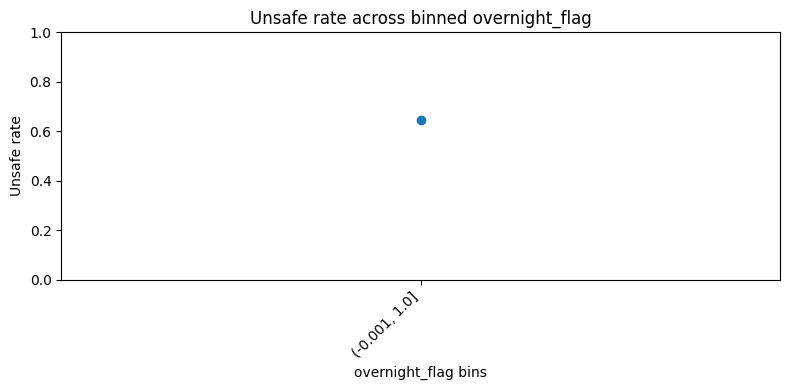

In [ ]:
binned_results = {}

for col in feature_cols:
    binned_results[col] = plot_event_rate_by_bins(model_df, col, q=10)

features are flat that consider to remove:
* pct_near_low
* pct_near_high
* pct_below_low
* pct_above_high
* overnight_flag



In [ ]:
features_to_drop = [
    "pct_near_low",
    "pct_near_high",
    "pct_below_low",
    "pct_above_high",
    "overnight_flag"
]

selected_features_v1 = [col for col in feature_cols if col not in features_to_drop]

print("Original feature_cols:", feature_cols)
print("selected_features_v1:", selected_features_v1)

Original feature_cols: ['mean_glucose', 'min_glucose', 'max_glucose', 'last_glucose', 'slope', 'delta_glucose', 'std_glucose', 'range_glucose', 'mean_abs_change', 'dist_low', 'dist_high', 'dist_nearest', 'pct_near_low', 'pct_near_high', 'pct_below_low', 'pct_above_high', 'mean_gap', 'gap_min', 'num_readings', 'hour', 'weekday', 'overnight_flag']
selected_features_v1: ['mean_glucose', 'min_glucose', 'max_glucose', 'last_glucose', 'slope', 'delta_glucose', 'std_glucose', 'range_glucose', 'mean_abs_change', 'dist_low', 'dist_high', 'dist_nearest', 'mean_gap', 'gap_min', 'num_readings', 'hour', 'weekday']


next, we examined the correlation between features.

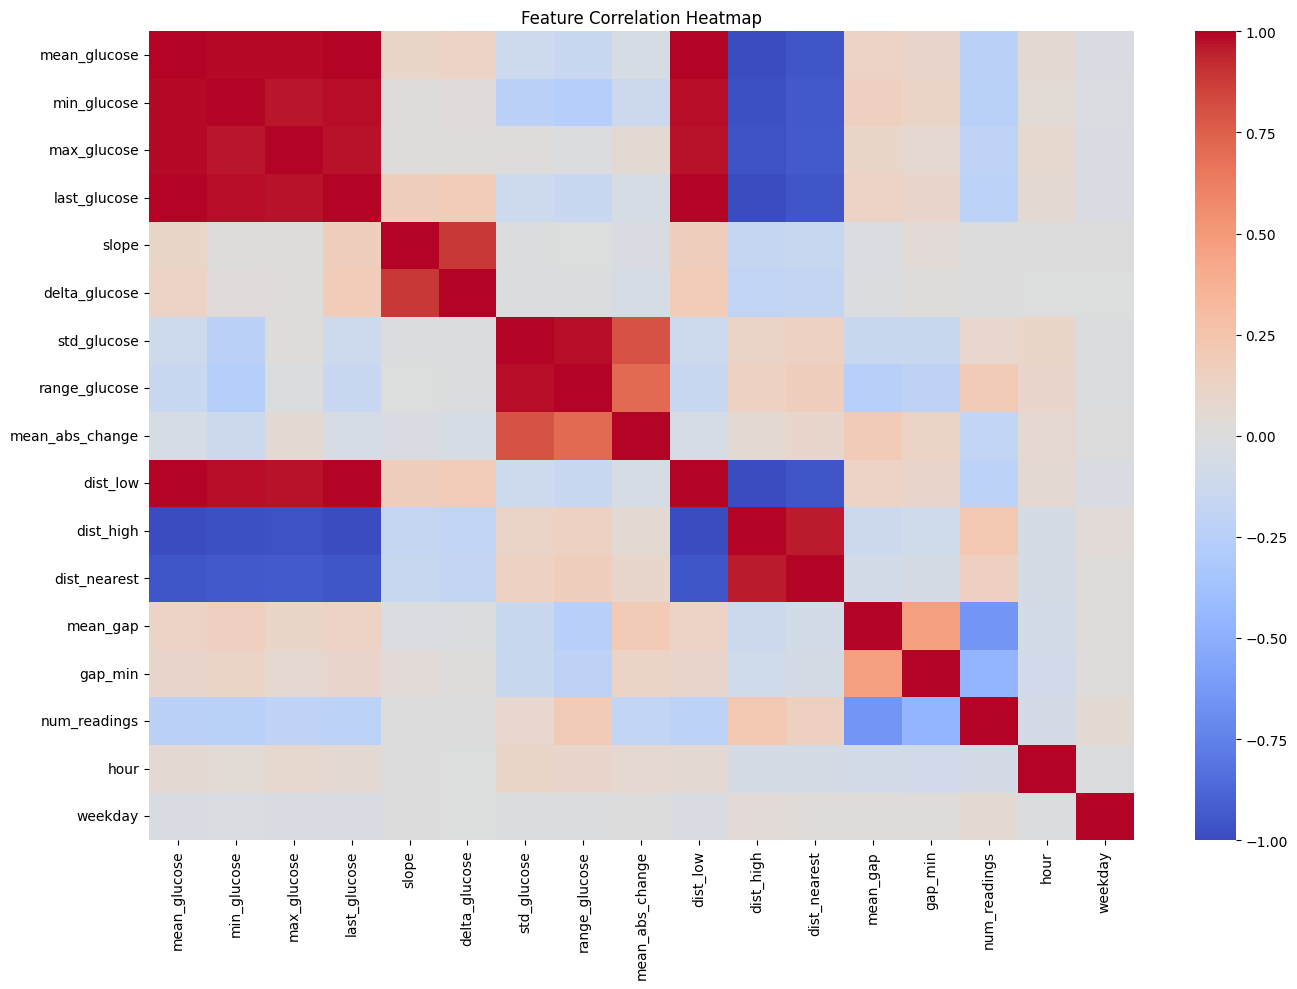

In [ ]:
# Correlation Heatmap
corr_df = model_df[selected_features_v1].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# list highly correlated pairs
corr_pairs = (
    corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "corr"]
corr_pairs["abs_corr"] = corr_pairs["corr"].abs()

high_corr_pairs = corr_pairs.sort_values("abs_corr", ascending=False)
high_corr_pairs
# high_corr_pairs[high_corr_pairs["abs_corr"] >= 0.85]

,feature_1,feature_2,corr,abs_corr
50,last_glucose,dist_low,1.000000,1.000000
51,last_glucose,dist_high,-1.000000,1.000000
108,dist_low,dist_high,-1.000000,1.000000
2,mean_glucose,last_glucose,0.996859,0.996859
9,mean_glucose,dist_high,-0.996859,0.996859
...,...,...,...,...
67,slope,num_readings,0.005948,0.005948
68,slope,hour,0.004096,0.004096
79,delta_glucose,hour,-0.001836,0.001836
69,slope,weekday,0.001030,0.001030


The above correlation table tells that there are several features are basically the same signal:
* last_glucose vs dist_low --> 1.00
* last_glucose vs dist_low --> -1.00
* dist_low vs dist_high --> -1.00

--> we can only keep last_glucose

Also, thre're some redundancies:
* mean_glucose vs last/min/max_glucose
* min_glucose vs max_glucose
* std_glucose vs range_glucose

--> we can keep mean_glucose, std_glucose

In [ ]:
features_to_drop_2 = [
    "dist_low",
    "dist_high",
    "max_glucose",
    "min_glucose",
    "range_glucose"
]

selected_features_v2 = [col for col in selected_features_v1 if col not in features_to_drop_2]

print("Original feature_cols:", feature_cols)
print("selected_features_v1:", selected_features_v1)
print("selected_features_v2:", selected_features_v2)

Original feature_cols: ['mean_glucose', 'min_glucose', 'max_glucose', 'last_glucose', 'slope', 'delta_glucose', 'std_glucose', 'range_glucose', 'mean_abs_change', 'dist_low', 'dist_high', 'dist_nearest', 'pct_near_low', 'pct_near_high', 'pct_below_low', 'pct_above_high', 'mean_gap', 'gap_min', 'num_readings', 'hour', 'weekday', 'overnight_flag']
selected_features_v1: ['mean_glucose', 'min_glucose', 'max_glucose', 'last_glucose', 'slope', 'delta_glucose', 'std_glucose', 'range_glucose', 'mean_abs_change', 'dist_low', 'dist_high', 'dist_nearest', 'mean_gap', 'gap_min', 'num_readings', 'hour', 'weekday']
selected_features_v2: ['mean_glucose', 'last_glucose', 'slope', 'delta_glucose', 'std_glucose', 'mean_abs_change', 'dist_nearest', 'mean_gap', 'gap_min', 'num_readings', 'hour', 'weekday']


# 🔆 Logistic Regression
Next, let's using the selected_features_v2 to train logistic regression with Leave-One-Dog-Out cross validation.

In [ ]:
model_df.head()

,ID,timestamp,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,gap_min,num_readings,...,pct_near_low,pct_near_high,pct_below_low,pct_above_high,hour,weekday,overnight_flag,glucose_category,normal_range,unsafe_now
0,canine1-001,2025-11-01 06:21:00,375.000000,375.0,375.0,0.000000,375.0,15.0,15.0,2,...,0.0,0.0,0.0,1.0,6,5,0,hyperglycemia,False,1
1,canine1-001,2025-11-01 06:36:00,373.669518,373.0,375.0,-0.264963,373.0,15.0,15.0,3,...,0.0,0.0,0.0,1.0,6,5,0,hyperglycemia,False,1
2,canine1-001,2025-11-01 06:51:00,374.526234,373.0,375.0,0.000000,375.0,15.0,15.0,4,...,0.0,0.0,0.0,1.0,6,5,0,hyperglycemia,False,1
3,canine1-001,2025-11-01 07:06:00,375.469626,373.0,376.0,0.116689,376.0,15.0,15.0,4,...,0.0,0.0,0.0,1.0,7,5,0,hyperglycemia,False,1
4,canine1-001,2025-11-01 07:21:00,371.953194,370.0,376.0,-0.350068,370.0,15.0,15.0,4,...,0.0,0.0,0.0,1.0,7,5,0,hyperglycemia,False,1


In [ ]:
model_df['dog_id'] = model_df['ID'].str[:7]
print(model_df[['ID', 'dog_id']].head())

            ID   dog_id
0  canine1-001  canine1
1  canine1-001  canine1
2  canine1-001  canine1
3  canine1-001  canine1
4  canine1-001  canine1


In [ ]:
# define trarget col
target = "unsafe_now"

# define input cols
input_cols = selected_features_v2

# define dog identifier
group_col = "dog_id"

In [ ]:
# model pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

In [ ]:
# model build
results = []

dogs = model_df[group_col].unique() # Get a list of all unique dog IDs for cross-validation

# Loop through each dog, using one dog's data as the test set and the rest for training
for test_dog in dogs:

    # Split data into training and testing sets based on the current test_dog
    train_df = model_df[model_df[group_col] != test_dog]
    test_df = model_df[model_df[group_col] == test_dog]

    # Prepare features (X) and target (y) for training
    X_train = train_df[selected_features_v2]
    y_train = train_df[target]

    # Prepare features (X) and target (y) for testing
    X_test = test_df[selected_features_v2]
    y_test = test_df[target]

    pipeline.fit(X_train, y_train) # Train the model pipeline on the current training set

    preds = pipeline.predict(X_test) # Make binary predictions on the test set
    probs = pipeline.predict_proba(X_test)[:,1] # Get probability estimates for the positive class

    # Calculate confusion matrix components (True Negative, False Positive, False Negative, True Positive)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    # Append calculated performance metrics for the current test_dog to the results list
    results.append({
        "test_dog": test_dog,
        "roc_auc": roc_auc_score(y_test, probs),
        "pr_auc": average_precision_score(y_test, probs),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

results_df = pd.DataFrame(results) # Convert the list of results into a DataFrame

results_df # Display the DataFrame containing metrics for each dog

,test_dog,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp
0,canine1,0.992269,0.996365,0.989401,0.941503,0.964858,978,20,116,1867
1,canine2,0.973668,0.966903,0.950156,0.840220,0.891813,575,16,58,305
2,canine3,0.995361,0.997353,0.987239,0.970031,0.978559,2043,41,98,3172
3,canine4,0.992511,0.968205,0.922438,0.864935,0.892761,1908,28,52,333
4,canine5,0.996041,0.998945,0.989765,0.978261,0.983979,1152,47,101,4545
5,canine6,0.995067,0.997883,0.988145,0.955563,0.971581,3992,105,407,8752


In [ ]:
results_df.mean(numeric_only=True)

,0
roc_auc,0.990820
pr_auc,0.987609
precision,0.971191
recall,0.925085
f1,0.947259
tn,1774.666667
fp,42.833333
fn,138.666667
tp,3162.333333


In [ ]:
results_df.sort_values("recall")

,test_dog,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp
1,canine2,0.973668,0.966903,0.950156,0.840220,0.891813,575,16,58,305
3,canine4,0.992511,0.968205,0.922438,0.864935,0.892761,1908,28,52,333
0,canine1,0.992269,0.996365,0.989401,0.941503,0.964858,978,20,116,1867
5,canine6,0.995067,0.997883,0.988145,0.955563,0.971581,3992,105,407,8752
2,canine3,0.995361,0.997353,0.987239,0.970031,0.978559,2043,41,98,3172
4,canine5,0.996041,0.998945,0.989765,0.978261,0.983979,1152,47,101,4545


In [ ]:
# Aggregate Confusion Matrix
total_tn = results_df["tn"].sum()
total_fp = results_df["fp"].sum()
total_fn = results_df["fn"].sum()
total_tp = results_df["tp"].sum()

print("Confusion Matrix (Aggregated)")
print([[total_tn, total_fp],
       [total_fn, total_tp]])

Confusion Matrix (Aggregated)
[[np.int64(10648), np.int64(257)], [np.int64(832), np.int64(18974)]]



Aggregate Accuracy: 0.9645
Aggregate Precision: 0.9866
Aggregate Recall: 0.9580


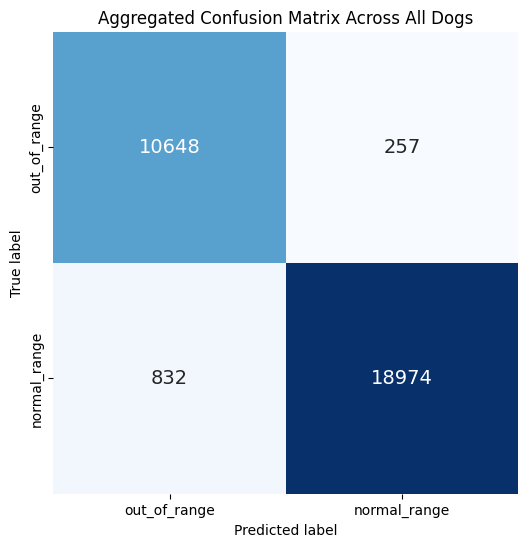

In [ ]:
# Calculate Aggregate Metrics
total_samples = total_tn + total_fp + total_fn + total_tp
aggregate_accuracy = (total_tp + total_tn) / total_samples
# Precision: TP / (TP + FP)
aggregate_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
# Recall: TP / (TP + FN)
aggregate_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0

print(f"\nAggregate Accuracy: {aggregate_accuracy:.4f}")
print(f"Aggregate Precision: {aggregate_precision:.4f}")
print(f"Aggregate Recall: {aggregate_recall:.4f}")

# Visualize the Aggregated Confusion Matrix
cm = np.array([[
    total_tn, total_fp],
    [total_fn, total_tp
]])

# Define target names as per notebook context for clarity
target_names = ["out_of_range", "normal_range"]

plt.figure(figsize = (6, 6))
sns.heatmap(
    cm,
    annot = True, annot_kws = {"size": 14},
    fmt = "d", cmap = "Blues",
    cbar = False,
    xticklabels = target_names,
    yticklabels = target_names
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("Aggregated Confusion Matrix Across All Dogs")
plt.show()

To reduce the FN, let's test with some lower thresholds.

From the results, 0.3 is the best balanced threshold. Compared with the default 0.5:
* Recall improves from 0.956 → 0.980
* FN drops a lot from 407 → 179
* Precision only drops slightly from 0.988 → 0.973
* F1 is actually the highest at 0.977

In [ ]:
thresholds = [0.2, 0.3, 0.4, 0.5]

for t in thresholds:

    preds = (probs > t).astype(int)

    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    f1 = f1_score(y_test, preds)

    print(
        f"Threshold {t}: "
        f"Recall={recall:.3f}, "
        f"Precision={precision:.3f}, "
        f"F1={f1:.3f}, "
        f"FN={fn}, FP={fp}, TP={tp}, TN={tn}"
    )

Threshold 0.2: Recall=0.990, Precision=0.955, F1=0.972, FN=94, FP=425, TP=9065, TN=3672
Threshold 0.3: Recall=0.980, Precision=0.973, F1=0.977, FN=179, FP=250, TP=8980, TN=3847
Threshold 0.4: Recall=0.970, Precision=0.983, F1=0.976, FN=278, FP=157, TP=8881, TN=3940
Threshold 0.5: Recall=0.956, Precision=0.988, F1=0.972, FN=407, FP=105, TP=8752, TN=3992


# break

below is the original code

In [ ]:
def feature_engineering(
    df,
    window_default = 60,
    window_max = 120,
    decay_min = 15
    ):
  """
  This function computes features using the fixed-length sliding window.
  If the dataset has data from less than 30 minutes, we take in what is available within the max window of 60 minutes.
  We also weigh the past glucose measures according to their recency using decay_min,
  which controls how quickly older points are down-weighted
  """

  features = []

  # sort by timestamp and make ID as a column
  for id, group in df.groupby("ID"):
    group = group.sort_values("timestamp").reset_index(drop = True)

    # now getting stats for the past 30 minutes
    for i, row in group.iterrows():
      window_start = row["timestamp"] - pd.Timedelta(minutes = window_default)
      lookback_start = row["timestamp"] - pd.Timedelta(minutes = window_max)

      # df of observations within the window frame being [past 30 minutes, current time)
      time_window = group[(group["timestamp"] >= window_start) & (group["timestamp"] < row["timestamp"])]

      # if there is none, go and look back up until 60 minutes
      if len(time_window) == 0:
        time_window = group[(group["timestamp"] >= lookback_start) & (group["timestamp"] < row["timestamp"])]

      # if there is still none, skip row
      if len(time_window) == 0:
        continue


      # get min/max/last glucose
      min_glucose = time_window["glucose"].min()
      max_glucose = time_window["glucose"].max()
      last_glucose = time_window["glucose"].iloc[-1]

      # weighting by gap in minutes from the current datapoint
      time_gap = (row["timestamp"] - time_window["timestamp"]).dt.total_seconds()/60
      weights = np.exp(-(time_gap/decay_min))

      # weighted mean
      weighted_mean = np.average(time_window["glucose"], weights = weights)

      # weighted slope
      weighted_time = np.sum(weights * time_window["gap_min"].fillna(0))

      # skip if there's no valid past gaps to compute slope
      if weighted_time == 0:
        continue
      else:
        # overall change within the time window
        slope = (last_glucose - time_window["glucose"].iloc[0])/weighted_time

      # mean gap
      mean_gap = time_window["gap_min"].mean()

      # now appending all the features into one place
      features.append({
          "ID": id,
          "timestamp": row["timestamp"],
          "mean_glucose": weighted_mean,
          "min_glucose": min_glucose,
          "max_glucose": max_glucose,
          "slope": slope,
          "last_glucose": last_glucose,
          "mean_gap": mean_gap,
          "gap_min": row["gap_min"],
          "num_readings": len(time_window),
          "glucose_category": row["glucose_category"],
          "normal_range": row["normal_range"]
      })


  return pd.DataFrame(features)

# 🔆 Genrating Features

In [ ]:
features = feature_engineering(final_df, window_default = 30, window_max = 60)

In [ ]:
final_df.groupby("ID").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min
0,canine1-001,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN
1,canine1-001,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0
95,canine1-002,2025-11-02 07:54:00,450.0,hyperglycemia,False,NaN
96,canine1-002,2025-11-02 08:08:00,447.0,hyperglycemia,False,14.0


We can see that the first data point now starts at 30 minutes after the first measurement

In [ ]:
features.groupby("ID").head(2).head(4)

,ID,timestamp,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,gap_min,num_readings,glucose_category,normal_range
0,canine1-001,2025-11-01 06:21:00,375.000000,375.0,375.0,0.000000,375.0,15.0,15.0,2,hyperglycemia,False
1,canine1-001,2025-11-01 06:36:00,373.537883,373.0,375.0,-0.264963,373.0,15.0,15.0,2,hyperglycemia,False
93,canine1-002,2025-11-02 08:09:00,447.846747,447.0,450.0,-0.229058,447.0,14.0,1.0,2,hyperglycemia,False
94,canine1-002,2025-11-02 08:12:00,451.386428,447.0,456.0,0.519853,456.0,7.5,3.0,3,hyperglycemia,False


# 🔆 Train/test split
We split the data in a time-based manner per ID
Specifically,
* first 80% of the data: train set
* later 20% of the data: test set

In [ ]:
train_list, test_list = [], []

for id, group in features.groupby("ID"):
  # again, making sure that we have correct order in time
  group = group.sort_values("timestamp")

  # get length of the group to split 80/20
  group_length = len(group)
  split_idx = int(group_length * .8)

  # splitting
  train_list.append(group.iloc[:split_idx])
  test_list.append(group.iloc[split_idx:])

  # get train/test sets in dataframe format
  train_df = pd.concat(train_list)
  test_df = pd.concat(test_list)

In [ ]:
# check
train_df.head()

,ID,timestamp,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,gap_min,num_readings,glucose_category,normal_range
0,canine1-001,2025-11-01 06:21:00,375.000000,375.0,375.0,0.000000,375.0,15.0,15.0,2,hyperglycemia,False
1,canine1-001,2025-11-01 06:36:00,373.537883,373.0,375.0,-0.264963,373.0,15.0,15.0,2,hyperglycemia,False
2,canine1-001,2025-11-01 06:51:00,374.462117,373.0,375.0,0.264963,375.0,15.0,15.0,2,hyperglycemia,False
3,canine1-001,2025-11-01 07:06:00,375.731059,375.0,376.0,0.132482,376.0,15.0,15.0,2,hyperglycemia,False
4,canine1-001,2025-11-01 07:21:00,371.613649,370.0,376.0,-0.794889,370.0,15.0,15.0,2,hyperglycemia,False


In [ ]:
test_df.head()

,ID,timestamp,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,gap_min,num_readings,glucose_category,normal_range
74,canine1-001,2025-11-01 23:52:00,326.840946,322.0,340.0,-2.384668,322.0,15.000000,15.0,2,hyperglycemia,False
75,canine1-001,2025-11-02 00:07:00,313.227297,310.0,322.0,-1.589779,310.0,15.000000,15.0,2,hyperglycemia,False
76,canine1-001,2025-11-02 00:12:00,302.689414,300.0,310.0,-0.680183,300.0,15.000000,5.0,2,hyperglycemia,False
77,canine1-001,2025-11-02 00:22:00,296.281035,290.0,310.0,-1.977202,290.0,11.666667,10.0,3,hyperglycemia,False
78,canine1-001,2025-11-02 00:37:00,296.207843,290.0,300.0,-0.300607,298.0,10.000000,15.0,3,hyperglycemia,False


In [ ]:
print(f"Number of IDs in train set: {train_df["ID"].nunique()}")
print(f"Number of IDs in test set: {test_df["ID"].nunique()}")

print(f"Train set length: {len(train_df)}")
print(f"Test set length: {len(test_df)}")

Number of IDs in train set: 298
Number of IDs in test set: 298
Train set length: 24444
Test set length: 6267


# 🔆 Features and Label (Setting 'target')

In [ ]:
input_cols = [
    "mean_glucose", "min_glucose", "max_glucose", "last_glucose",
    "slope",
    "mean_gap", "gap_min",
    "num_readings"
    ]

In [ ]:
# can change to glucose_category later
target = "normal_range"

In [ ]:
from prompt_toolkit.shortcuts.progress_bar.formatters import Label
X_train = train_df[input_cols]
X_test = test_df[input_cols]

le = LabelEncoder()
y_train = le.fit_transform(train_df[target])
y_test = le.transform(test_df[target])

# 🔆 Checking Class distribution in train set

Here, we can see that our class in train set is moderately imbalanced, with approximately 36% is glucose levels in **normal range** and **64% in dangerous zone**

Decisions:
* 36% of 'normal' range observations sems to be okay
* the class imbalance can be further addressed by *class_weight = 'balanced'* in lr modeling phase

But, just in case, we also make balanced dataset for further model performance evaluation comparison

In [ ]:
# check how the le was done
print(dict(zip(le.classes_, range(len(le.classes_)))))

{np.False_: 0, np.True_: 1}


In [ ]:
train_class_counts = pd.Series(y_train).value_counts()
print(f"Initial train class distribution:\n{train_class_counts}")

print(f"Initial train class distribution in proportion:\n{train_class_counts/len(y_train)}")

Initial train class distribution:
0    15665
1     8779
Name: count, dtype: int64
Initial train class distribution in proportion:
0    0.640853
1    0.359147
Name: count, dtype: float64


## ⭐ Balancing class distribution in train set by oversampling

In [ ]:
max_count = train_class_counts.max()
train_oversampled = []

for cls, count in train_class_counts.items():
    idx = np.where(y_train == cls)[0]
    df_cls = train_df.iloc[idx]
    if count < max_count:
        df_cls_up = resample(df_cls, replace=True, n_samples=max_count, random_state=42)
    else:
        df_cls_up = df_cls
    train_oversampled.append(df_cls_up)

train_df_bal = pd.concat(train_oversampled)

X_train_bal = train_df_bal[input_cols]
y_train_bal = le.transform(train_df_bal[target])

In [ ]:
# check that the balancing worked
train_bal_class_counts = pd.Series(y_train_bal).value_counts()
print(f"Train class distribution after balancing:\n{train_bal_class_counts}")

print(f"Train class distribution in proportion after balancing:\n{train_bal_class_counts/len(y_train_bal)}")

Train class distribution after balancing:
0    15665
1    15665
Name: count, dtype: int64
Train class distribution in proportion after balancing:
0    0.5
1    0.5
Name: count, dtype: float64


# 🔆 Model

## ⭐ Imbalanced train set

### Scaling features

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# model initialization
model = LogisticRegression(
    max_iter = 1000,
    # note: for multi-class classification for predicting glucose_category, use "multinomial"
    multi_class = "auto",
    solver = "lbfgs",
    # automatically handling imbalanced class
    class_weight = "balanced"
)

model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000, multi_class='auto')

### ▶ Evaluation

In [ ]:
# for clearer interpretation, set target names for 0, 1 in normal_range
target_names = ["out_of_range", "normal_range"]

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names = target_names))

              precision    recall  f1-score   support

out_of_range       0.99      0.96      0.98      4141
normal_range       0.93      0.98      0.95      2126

    accuracy                           0.97      6267
   macro avg       0.96      0.97      0.96      6267
weighted avg       0.97      0.97      0.97      6267



## ⭐ Balanced dataset

In [ ]:
X_train_scaled_bal = scaler.fit_transform(X_train_bal)
X_test_scaled_bal = scaler.transform(X_test)

In [ ]:
# model initialization
model_bal = LogisticRegression(
    max_iter = 1000,
    # note: for multi-class classification for predicting glucose_category, use "multinomial"
    multi_class = "auto",
    solver = "lbfgs",
    # can omit this part as the data is already balanced
    # class_weight = "balanced"
)

model_bal.fit(X_train_scaled_bal, y_train_bal)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='auto')

#### ▶ Evaluation

In [ ]:
target_names = ["out_of_range", "normal_range"]

y_pred_bal = model_bal.predict(X_test_scaled)

print(classification_report(y_test, y_pred_bal, target_names = target_names))

              precision    recall  f1-score   support

out_of_range       1.00      0.86      0.93      4141
normal_range       0.79      1.00      0.88      2126

    accuracy                           0.91      6267
   macro avg       0.89      0.93      0.90      6267
weighted avg       0.93      0.91      0.91      6267



# ✅ Final Summary

We see that for binary logistic regression model, the combination of **imbalanced dataset & class_weight = "balanced" in the model argument performing better** than making the class balanced prior to the model fitting.
Below is the confusion matrix for the model that used imbalanced dataset.

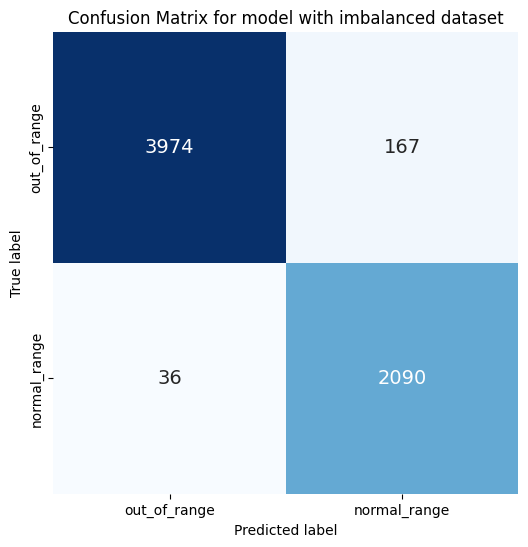

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6, 6))
sns.heatmap(
    cm,
    annot = True, annot_kws = {"size": 14},
    fmt = "d", cmap = "Blues",
    cbar = False,
    xticklabels = target_names,
    yticklabels = target_names
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("Confusion Matrix for model with imbalanced dataset")
plt.show()

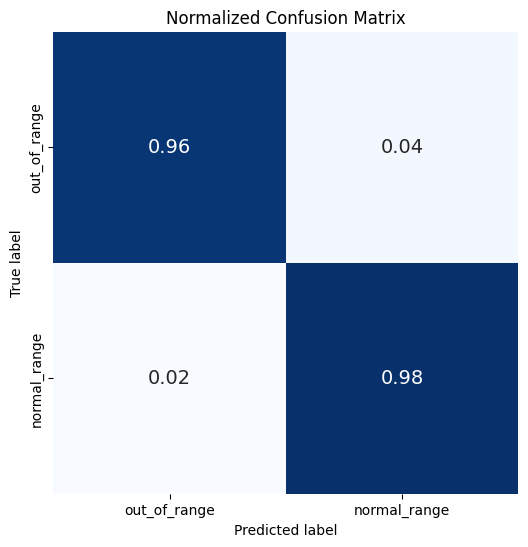

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,6))
sns.heatmap(
    cm_norm,
    annot=True, annot_kws={"size": 14},
    fmt='.2f',
    cmap='Blues', cbar = False,
    xticklabels= target_names,
    yticklabels= target_names
    )
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Normalized Confusion Matrix')
plt.show()